In [1]:
import os
import pandas as pd

# Use double quotes around the raw string – no escape issues
folder_path = r"C:\Users\B1Bash\Desktop\Gorgeous\my_portfolio\Portfolio_2"
file_name = 'heart_failure_clinical_records_dataset.csv'
full_path = os.path.join(folder_path, file_name)

# Check if the file exists
if os.path.exists(full_path):
    df = pd.read_csv(full_path)
    print("✅ Dataset loaded successfully!")
    print(f"Shape: {df.shape}")
    print("First 5 rows:")
    print(df.head())
else:
    print(f"❌ File not found at: {full_path}")
    print("Please verify the file name and path.")
    # List contents of the folder to help debug
    if os.path.exists(folder_path):
        print("\nContents of the folder:")
        for item in os.listdir(folder_path):
            print(f"  - {item}")
    else:
        print(f"The folder '{folder_path}' does not exist. Check your path.")

✅ Dataset loaded successfully!
Shape: (299, 13)
First 5 rows:
    age  anaemia  creatinine_phosphokinase  diabetes  ejection_fraction  \
0  75.0        0                       582         0                 20   
1  55.0        0                      7861         0                 38   
2  65.0        0                       146         0                 20   
3  50.0        1                       111         0                 20   
4  65.0        1                       160         1                 20   

   high_blood_pressure  platelets  serum_creatinine  serum_sodium  sex  \
0                    1  265000.00               1.9           130    1   
1                    0  263358.03               1.1           136    1   
2                    0  162000.00               1.3           129    1   
3                    0  210000.00               1.9           137    1   
4                    0  327000.00               2.7           116    0   

   smoking  time  DEATH_EVENT  
0        0

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score

# Models
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Set style for better plots
sns.set_style("whitegrid")
%matplotlib inline

In [3]:
print("Dataset Info:")
df.info()

print("\nDescriptive Statistics:")
df.describe()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 30.5 KB

Des

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
count,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.00000,299.000000,299.000000,299.00000,299.000000,299.00000
mean,60.833893,0.431438,581.839465,0.418060,38.083612,0.351171,263358.029264,1.39388,136.625418,0.648829,0.32107,130.260870,0.32107
std,11.894809,0.496107,970.287881,0.494067,11.834841,0.478136,97804.236869,1.03451,4.412477,0.478136,0.46767,77.614208,0.46767
min,40.000000,0.000000,23.000000,0.000000,14.000000,0.000000,25100.000000,0.50000,113.000000,0.000000,0.00000,4.000000,0.00000
25%,51.000000,0.000000,116.500000,0.000000,30.000000,0.000000,212500.000000,0.90000,134.000000,0.000000,0.00000,73.000000,0.00000
50%,60.000000,0.000000,250.000000,0.000000,38.000000,0.000000,262000.000000,1.10000,137.000000,1.000000,0.00000,115.000000,0.00000
75%,70.000000,1.000000,582.000000,1.000000,45.000000,1.000000,303500.000000,1.40000,140.000000,1.000000,1.00000,203.000000,1.00000
max,95.000000,1.000000,7861.000000,1.000000,80.000000,1.000000,850000.000000,9.40000,148.000000,1.000000,1.00000,285.000000,1.00000


In [4]:
print("Missing Values per Column:")
print(df.isnull().sum())

Missing Values per Column:
age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64


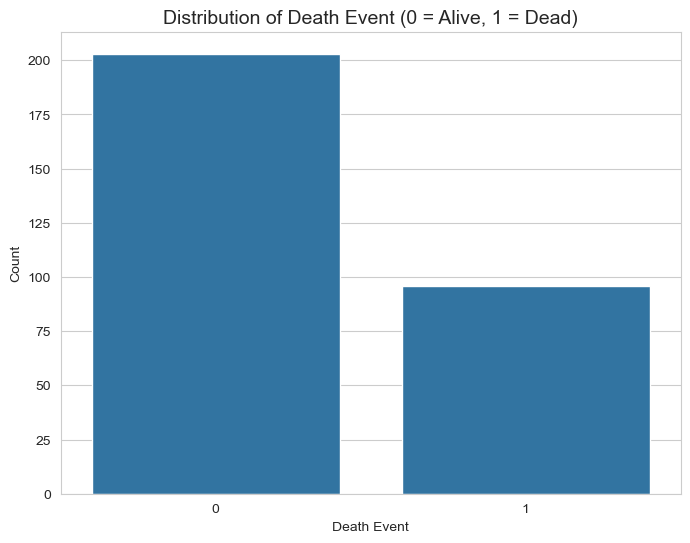

Target Distribution:
DEATH_EVENT
0    203
1     96
Name: count, dtype: int64
Mortality Rate: 32.11%


In [5]:
plt.figure(figsize=(8, 6))
sns.countplot(x='DEATH_EVENT', data=df)
plt.title('Distribution of Death Event (0 = Alive, 1 = Dead)', fontsize=14)
plt.xlabel('Death Event')
plt.ylabel('Count')
plt.show()

print("Target Distribution:")
print(df['DEATH_EVENT'].value_counts())
print(f"Mortality Rate: {df['DEATH_EVENT'].mean()*100:.2f}%")

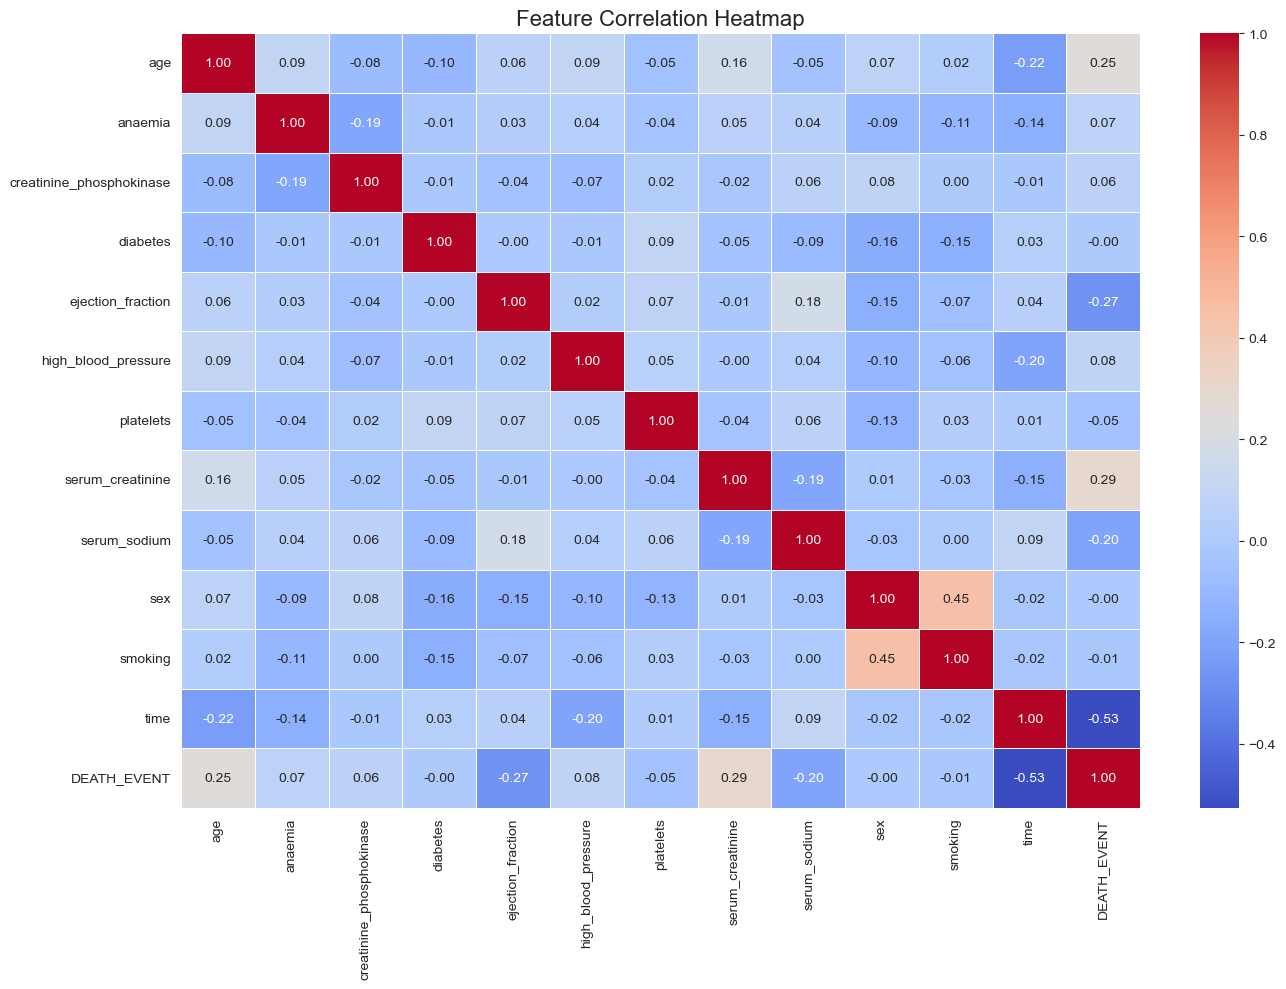

In [6]:
plt.figure(figsize=(14, 10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=16)
plt.tight_layout()
plt.show()

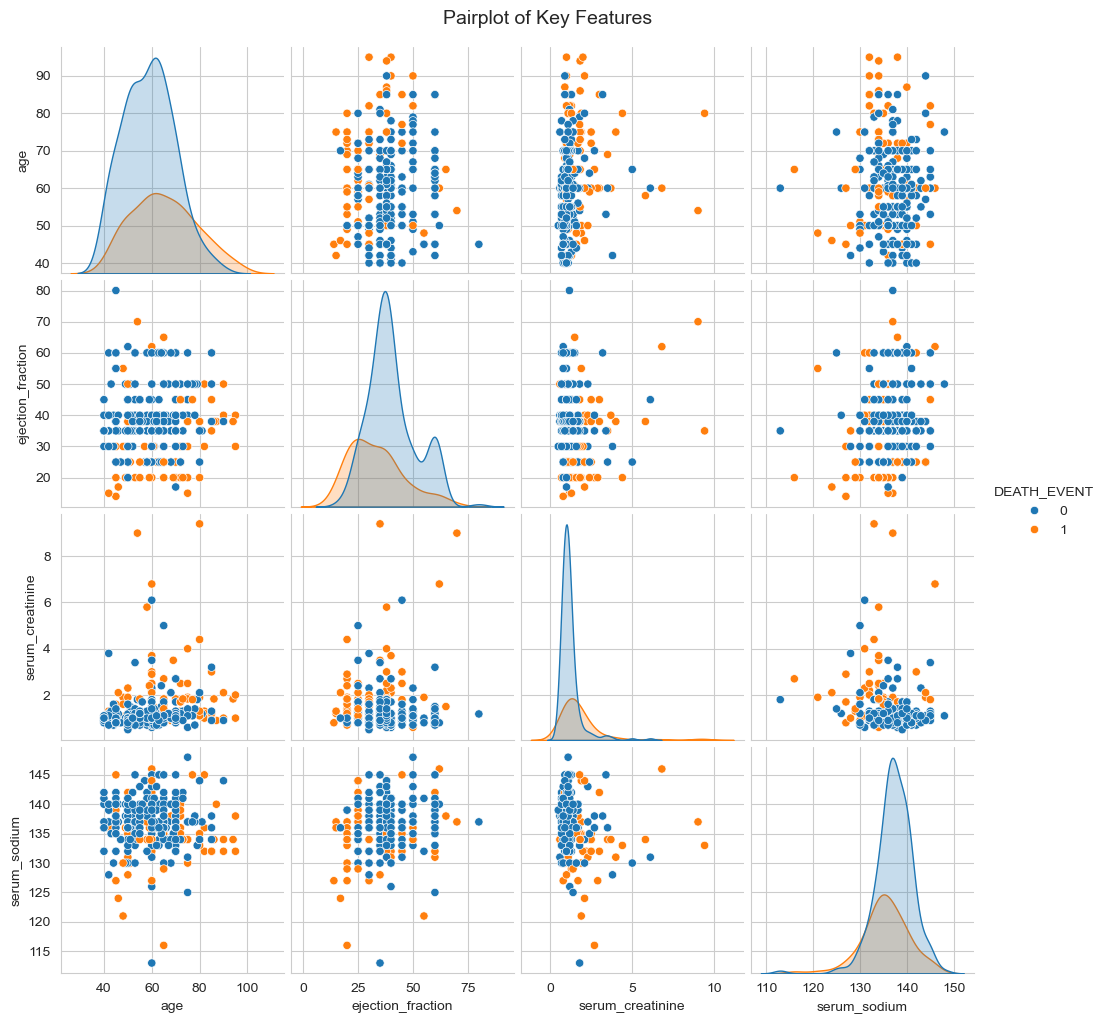

In [7]:
sns.pairplot(df[['age', 'ejection_fraction', 'serum_creatinine', 'serum_sodium', 'DEATH_EVENT']], 
             hue='DEATH_EVENT', diag_kind='kde')
plt.suptitle('Pairplot of Key Features', y=1.02, fontsize=14)
plt.show()

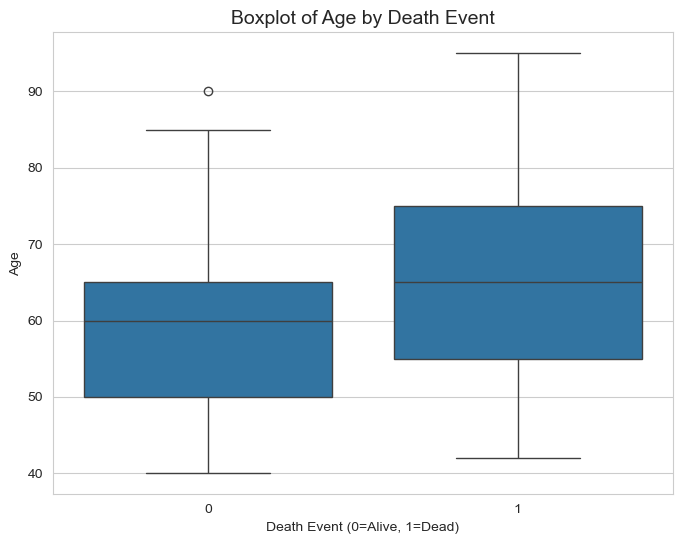

In [8]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='DEATH_EVENT', y='age', data=df)
plt.title('Boxplot of Age by Death Event', fontsize=14)
plt.xlabel('Death Event (0=Alive, 1=Dead)')
plt.ylabel('Age')
plt.show()

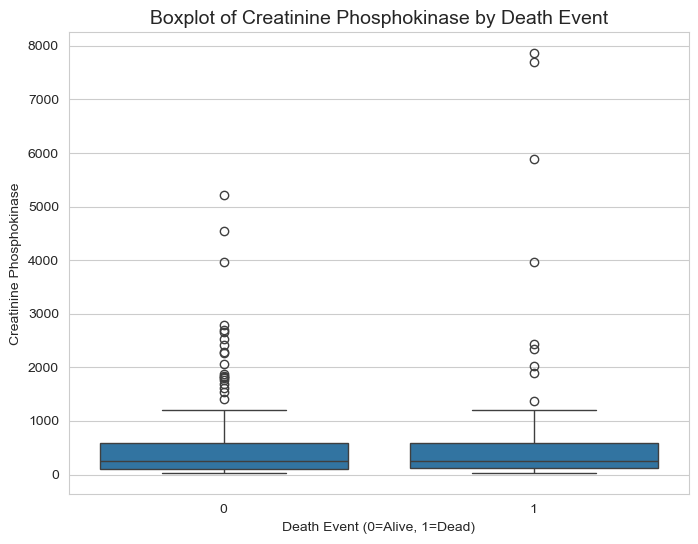

In [9]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='DEATH_EVENT', y='creatinine_phosphokinase', data=df)
plt.title('Boxplot of Creatinine Phosphokinase by Death Event', fontsize=14)
plt.xlabel('Death Event (0=Alive, 1=Dead)')
plt.ylabel('Creatinine Phosphokinase')
plt.show()

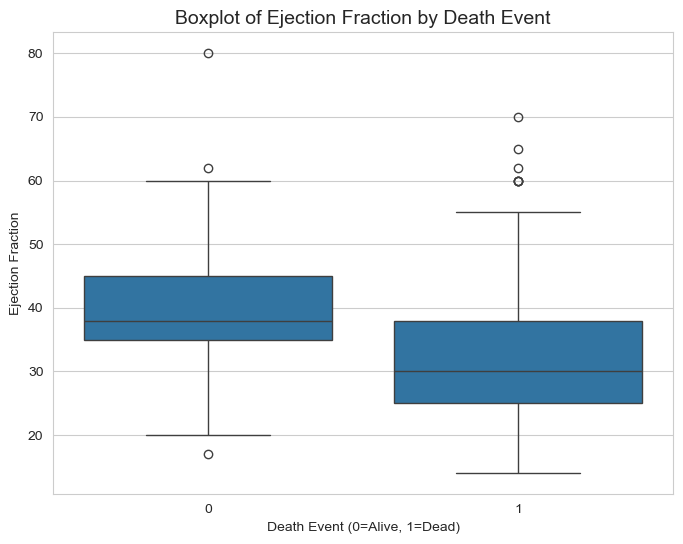

In [10]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='DEATH_EVENT', y='ejection_fraction', data=df)
plt.title('Boxplot of Ejection Fraction by Death Event', fontsize=14)
plt.xlabel('Death Event (0=Alive, 1=Dead)')
plt.ylabel('Ejection Fraction')
plt.show()

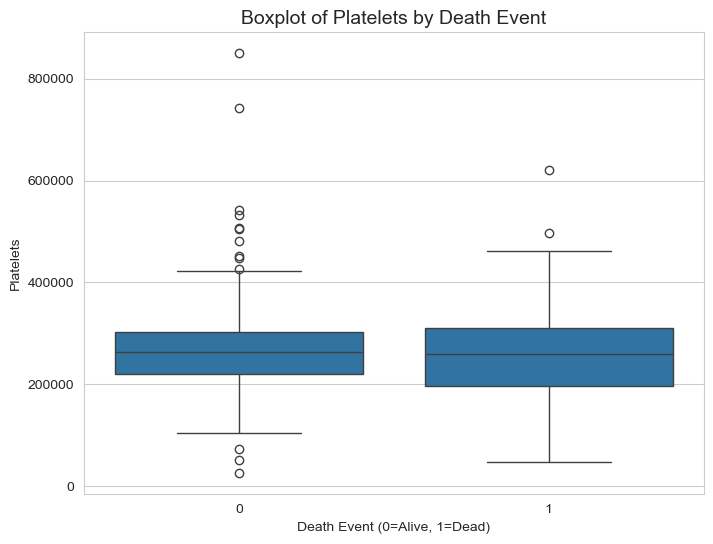

In [11]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='DEATH_EVENT', y='platelets', data=df)
plt.title('Boxplot of Platelets by Death Event', fontsize=14)
plt.xlabel('Death Event (0=Alive, 1=Dead)')
plt.ylabel('Platelets')
plt.show()

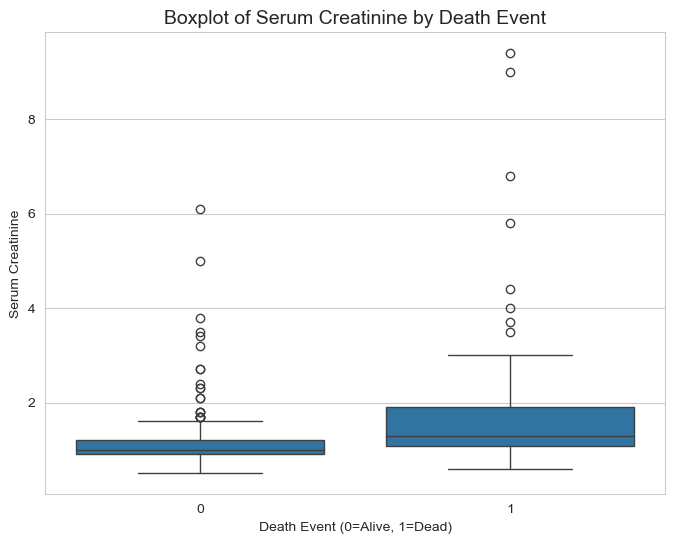

In [12]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='DEATH_EVENT', y='serum_creatinine', data=df)
plt.title('Boxplot of Serum Creatinine by Death Event', fontsize=14)
plt.xlabel('Death Event (0=Alive, 1=Dead)')
plt.ylabel('Serum Creatinine')
plt.show()

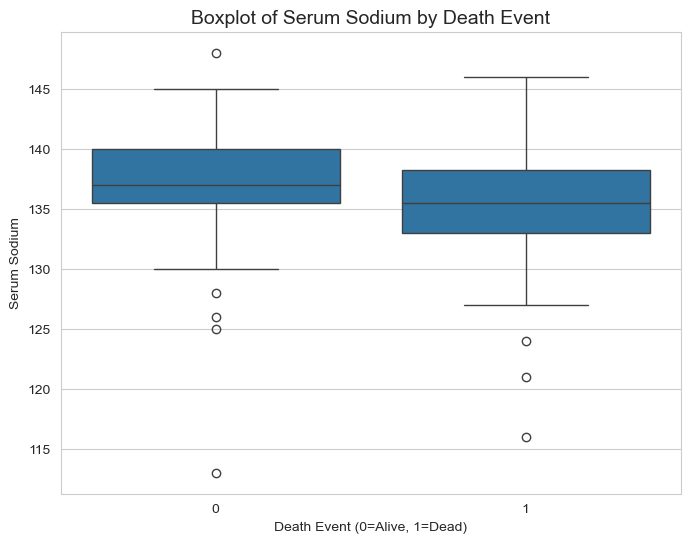

In [13]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='DEATH_EVENT', y='serum_sodium', data=df)
plt.title('Boxplot of Serum Sodium by Death Event', fontsize=14)
plt.xlabel('Death Event (0=Alive, 1=Dead)')
plt.ylabel('Serum Sodium')
plt.show()

In [14]:
X = df.drop('DEATH_EVENT', axis=1)
y = df['DEATH_EVENT']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Features columns: {list(X.columns)}")

Features shape: (299, 12)
Target shape: (299,)
Features columns: ['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes', 'ejection_fraction', 'high_blood_pressure', 'platelets', 'serum_creatinine', 'serum_sodium', 'sex', 'smoking', 'time']


In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")
print("\nTraining target distribution:")
print(y_train.value_counts())
print(f"Training mortality rate: {y_train.mean()*100:.2f}%")
print("\nTest target distribution:")
print(y_test.value_counts())
print(f"Test mortality rate: {y_test.mean()*100:.2f}%")

Training set size: 239 samples
Test set size: 60 samples

Training target distribution:
DEATH_EVENT
0    162
1     77
Name: count, dtype: int64
Training mortality rate: 32.22%

Test target distribution:
DEATH_EVENT
0    41
1    19
Name: count, dtype: int64
Test mortality rate: 31.67%


In [16]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed!")
print(f"Scaled training data shape: {X_train_scaled.shape}")
print(f"Scaled test data shape: {X_test_scaled.shape}")
print(f"\nMean of scaled training data (first 5 features): {X_train_scaled.mean(axis=0)[:5].round(4)}")
print(f"Std of scaled training data (first 5 features): {X_train_scaled.std(axis=0)[:5].round(4)}")

Feature scaling completed!
Scaled training data shape: (239, 12)
Scaled test data shape: (60, 12)

Mean of scaled training data (first 5 features): [ 0. -0.  0. -0.  0.]
Std of scaled training data (first 5 features): [1. 1. 1. 1. 1.]


In [17]:
models = {
    'SVM': SVC(kernel='rbf', probability=True, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

print("Models defined:")
for name in models.keys():
    print(f"  - {name}")

Models defined:
  - SVM
  - KNN
  - Logistic Regression
  - Decision Tree
  - Random Forest
  - Gradient Boosting


In [18]:
name = 'SVM'
model = models[name]

cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy')
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_proba)

print(f"\n{'='*50}")
print(f"{name} Performance:")
print(f"{'='*50}")
print(f"  CV Accuracy: {np.mean(cv_scores):.4f} (±{np.std(cv_scores):.4f})")
print(f"  Test Accuracy: {accuracy:.4f}")
print(f"  AUC-ROC: {auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


SVM Performance:
  CV Accuracy: 0.8075 (±0.0565)
  Test Accuracy: 0.7667
  AUC-ROC: 0.8447

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.93      0.84        41
           1       0.73      0.42      0.53        19

    accuracy                           0.77        60
   macro avg       0.75      0.67      0.69        60
weighted avg       0.76      0.77      0.75        60


Confusion Matrix:
[[38  3]
 [11  8]]


In [19]:
name = 'KNN'
model = models[name]

cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy')
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_proba)

print(f"\n{'='*50}")
print(f"{name} Performance:")
print(f"{'='*50}")
print(f"  CV Accuracy: {np.mean(cv_scores):.4f} (±{np.std(cv_scores):.4f})")
print(f"  Test Accuracy: {accuracy:.4f}")
print(f"  AUC-ROC: {auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


KNN Performance:
  CV Accuracy: 0.7617 (±0.0648)
  Test Accuracy: 0.7000
  AUC-ROC: 0.8004

Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.93      0.81        41
           1       0.57      0.21      0.31        19

    accuracy                           0.70        60
   macro avg       0.64      0.57      0.56        60
weighted avg       0.67      0.70      0.65        60


Confusion Matrix:
[[38  3]
 [15  4]]


In [20]:
name = 'Logistic Regression'
model = models[name]

cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy')
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_proba)

print(f"\n{'='*50}")
print(f"{name} Performance:")
print(f"{'='*50}")
print(f"  CV Accuracy: {np.mean(cv_scores):.4f} (±{np.std(cv_scores):.4f})")
print(f"  Test Accuracy: {accuracy:.4f}")
print(f"  AUC-ROC: {auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Logistic Regression Performance:
  CV Accuracy: 0.8367 (±0.0430)
  Test Accuracy: 0.8167
  AUC-ROC: 0.8588

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.93      0.87        41
           1       0.79      0.58      0.67        19

    accuracy                           0.82        60
   macro avg       0.81      0.75      0.77        60
weighted avg       0.81      0.82      0.81        60


Confusion Matrix:
[[38  3]
 [ 8 11]]


In [21]:
name = 'Decision Tree'
model = models[name]

cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy')
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_proba)

print(f"\n{'='*50}")
print(f"{name} Performance:")
print(f"{'='*50}")
print(f"  CV Accuracy: {np.mean(cv_scores):.4f} (±{np.std(cv_scores):.4f})")
print(f"  Test Accuracy: {accuracy:.4f}")
print(f"  AUC-ROC: {auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Decision Tree Performance:
  CV Accuracy: 0.7741 (±0.0547)
  Test Accuracy: 0.7333
  AUC-ROC: 0.6637

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.85      0.81        41
           1       0.60      0.47      0.53        19

    accuracy                           0.73        60
   macro avg       0.69      0.66      0.67        60
weighted avg       0.72      0.73      0.72        60


Confusion Matrix:
[[35  6]
 [10  9]]


In [22]:
name = 'Random Forest'
model = models[name]

cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy')
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_proba)

print(f"\n{'='*50}")
print(f"{name} Performance:")
print(f"{'='*50}")
print(f"  CV Accuracy: {np.mean(cv_scores):.4f} (±{np.std(cv_scores):.4f})")
print(f"  Test Accuracy: {accuracy:.4f}")
print(f"  AUC-ROC: {auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Random Forest Performance:
  CV Accuracy: 0.8494 (±0.0358)
  Test Accuracy: 0.8333
  AUC-ROC: 0.8909

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.93      0.88        41
           1       0.80      0.63      0.71        19

    accuracy                           0.83        60
   macro avg       0.82      0.78      0.79        60
weighted avg       0.83      0.83      0.83        60


Confusion Matrix:
[[38  3]
 [ 7 12]]


In [23]:
name = 'Gradient Boosting'
model = models[name]

cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy')
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_proba)

print(f"\n{'='*50}")
print(f"{name} Performance:")
print(f"{'='*50}")
print(f"  CV Accuracy: {np.mean(cv_scores):.4f} (±{np.std(cv_scores):.4f})")
print(f"  Test Accuracy: {accuracy:.4f}")
print(f"  AUC-ROC: {auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Gradient Boosting Performance:
  CV Accuracy: 0.8495 (±0.0442)
  Test Accuracy: 0.8333
  AUC-ROC: 0.8447

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.93      0.88        41
           1       0.80      0.63      0.71        19

    accuracy                           0.83        60
   macro avg       0.82      0.78      0.79        60
weighted avg       0.83      0.83      0.83        60


Confusion Matrix:
[[38  3]
 [ 7 12]]


In [24]:
results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1] if hasattr(model, 'predict_proba') else None
    
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy')
    
    results[name] = {
        'cv_mean_accuracy': np.mean(cv_scores),
        'cv_std': np.std(cv_scores),
        'test_accuracy': accuracy_score(y_test, y_pred),
        'auc_roc': roc_auc_score(y_test, y_pred_proba) if y_pred_proba is not None else None
    }

comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'CV Accuracy': [results[m]['cv_mean_accuracy'] for m in results],
    'CV Std': [results[m]['cv_std'] for m in results],
    'Test Accuracy': [results[m]['test_accuracy'] for m in results],
    'AUC-ROC': [results[m]['auc_roc'] for m in results]
})

comparison_df = comparison_df.sort_values('Test Accuracy', ascending=False)
print("Model Comparison:")
comparison_df

Model Comparison:


,Model,CV Accuracy,CV Std,Test Accuracy,AUC-ROC
4,Random Forest,0.849379,0.035792,0.833333,0.890886
5,Gradient Boosting,0.849468,0.044201,0.833333,0.844673
2,Logistic Regression,0.836702,0.042988,0.816667,0.858793
0,SVM,0.807535,0.056483,0.766667,0.844673
3,Decision Tree,0.774113,0.054721,0.733333,0.663671
1,KNN,0.761702,0.064758,0.700000,0.800385


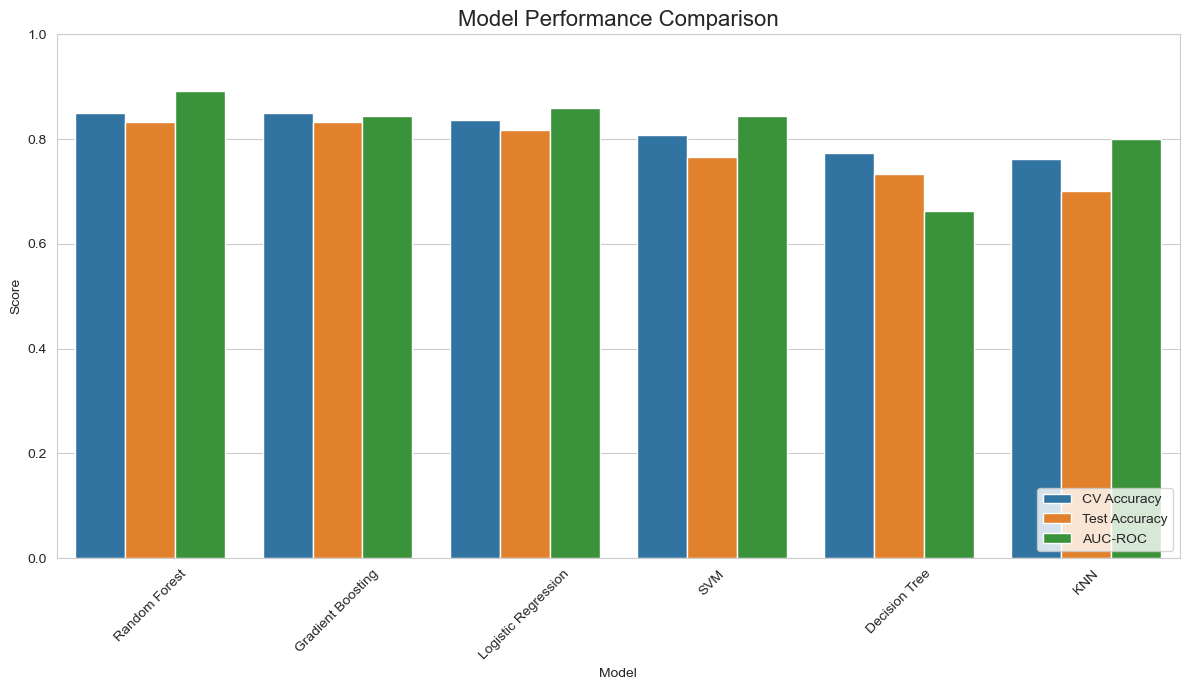

In [25]:
comparison_df_melted = comparison_df.melt(
    id_vars='Model', 
    value_vars=['CV Accuracy', 'Test Accuracy', 'AUC-ROC'],
    var_name='Metric', 
    value_name='Score'
)

plt.figure(figsize=(12, 7))
sns.barplot(x='Model', y='Score', hue='Metric', data=comparison_df_melted)
plt.title('Model Performance Comparison', fontsize=16)
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [26]:
print("--- Hyperparameter Tuning for Random Forest ---")

param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42), 
    param_grid_rf, 
    cv=5, 
    scoring='accuracy',
    n_jobs=-1
)

grid_rf.fit(X_train_scaled, y_train)

print(f"Best parameters: {grid_rf.best_params_}")
print(f"Best CV Accuracy: {grid_rf.best_score_:.4f}")

--- Hyperparameter Tuning for Random Forest ---
Best parameters: {'max_depth': None, 'min_samples_split': 10, 'n_estimators': 50}
Best CV Accuracy: 0.8703


In [27]:
best_rf = grid_rf.best_estimator_
y_pred_rf = best_rf.predict(X_test_scaled)
y_pred_proba_rf = best_rf.predict_proba(X_test_scaled)[:, 1]

test_acc = accuracy_score(y_test, y_pred_rf)
auc = roc_auc_score(y_test, y_pred_proba_rf)

print(f"Test Accuracy with tuned RF: {test_acc:.4f}")
print(f"AUC-ROC with tuned RF: {auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

Test Accuracy with tuned RF: 0.8000
AUC-ROC with tuned RF: 0.9140

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.90      0.86        41
           1       0.73      0.58      0.65        19

    accuracy                           0.80        60
   macro avg       0.78      0.74      0.75        60
weighted avg       0.79      0.80      0.79        60


Confusion Matrix:
[[37  4]
 [ 8 11]]


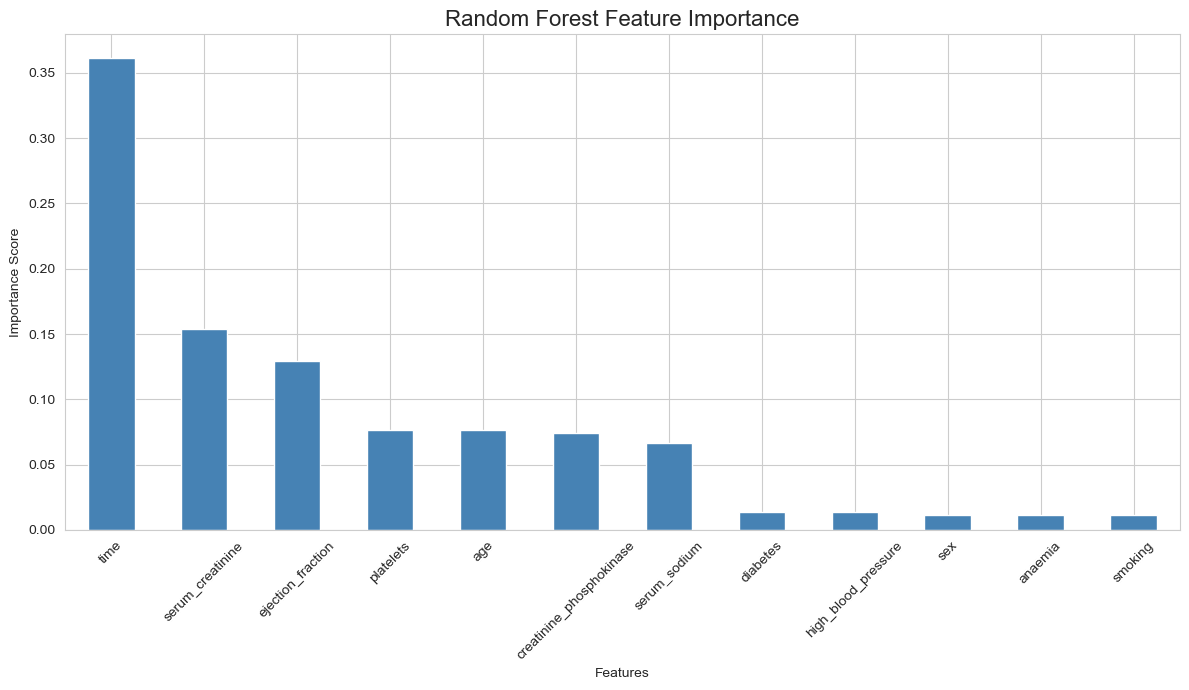


Top 10 Important Features (Random Forest):
time                        0.361383
serum_creatinine            0.154118
ejection_fraction           0.129121
platelets                   0.076820
age                         0.076779
creatinine_phosphokinase    0.074548
serum_sodium                0.066215
diabetes                    0.013931
high_blood_pressure         0.013373
sex                         0.011312
dtype: float64


In [28]:
rf_model = models['Random Forest']
feature_importance = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(12, 7))
feature_importance.plot(kind='bar', color='steelblue')
plt.title('Random Forest Feature Importance', fontsize=16)
plt.xlabel('Features')
plt.ylabel('Importance Score')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\nTop 10 Important Features (Random Forest):")
print(feature_importance.head(10))

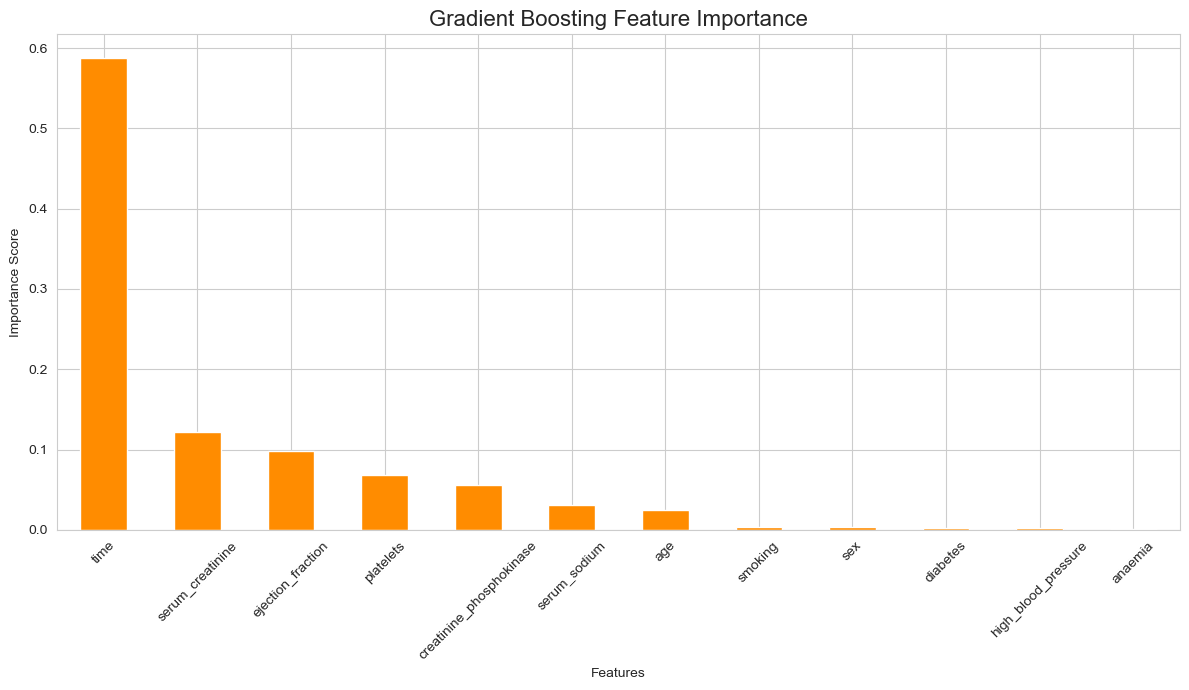


Top 10 Important Features (Gradient Boosting):
time                        0.587590
serum_creatinine            0.122385
ejection_fraction           0.098449
platelets                   0.068201
creatinine_phosphokinase    0.055924
serum_sodium                0.031526
age                         0.024156
smoking                     0.003155
sex                         0.002998
diabetes                    0.002411
dtype: float64


In [29]:
gb_model = models['Gradient Boosting']
gb_importance = pd.Series(gb_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(12, 7))
gb_importance.plot(kind='bar', color='darkorange')
plt.title('Gradient Boosting Feature Importance', fontsize=16)
plt.xlabel('Features')
plt.ylabel('Importance Score')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\nTop 10 Important Features (Gradient Boosting):")
print(gb_importance.head(10))

In [30]:
# Add tuned RF to comparison
comparison_df_updated = comparison_df.copy()

tuned_rf_row = pd.DataFrame({
    'Model': ['Tuned Random Forest'],
    'CV Accuracy': [grid_rf.best_score_],
    'CV Std': [np.std(grid_rf.cv_results_['mean_test_score'])],
    'Test Accuracy': [test_acc],
    'AUC-ROC': [auc]
})

comparison_df_updated = pd.concat([comparison_df_updated, tuned_rf_row], ignore_index=True)
comparison_df_updated = comparison_df_updated.sort_values('Test Accuracy', ascending=False)

print("Updated Model Comparison (with Tuned RF):")
comparison_df_updated

Updated Model Comparison (with Tuned RF):


,Model,CV Accuracy,CV Std,Test Accuracy,AUC-ROC
0,Random Forest,0.849379,0.035792,0.833333,0.890886
1,Gradient Boosting,0.849468,0.044201,0.833333,0.844673
2,Logistic Regression,0.836702,0.042988,0.816667,0.858793
6,Tuned Random Forest,0.870301,0.012613,0.800000,0.913992
3,SVM,0.807535,0.056483,0.766667,0.844673
4,Decision Tree,0.774113,0.054721,0.733333,0.663671
5,KNN,0.761702,0.064758,0.700000,0.800385


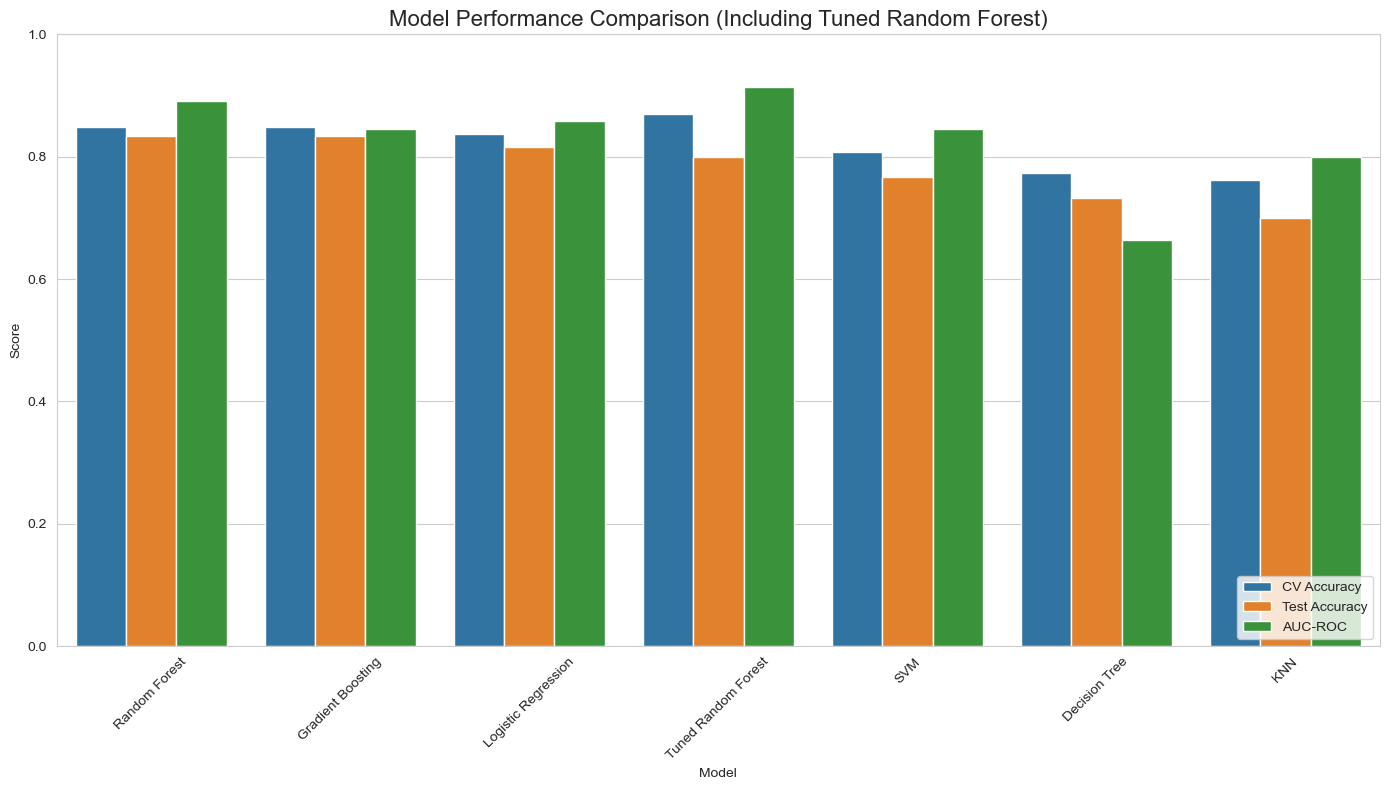

In [31]:
comparison_updated_melted = comparison_df_updated.melt(
    id_vars='Model', 
    value_vars=['CV Accuracy', 'Test Accuracy', 'AUC-ROC'],
    var_name='Metric', 
    value_name='Score'
)

plt.figure(figsize=(14, 8))
sns.barplot(x='Model', y='Score', hue='Metric', data=comparison_updated_melted)
plt.title('Model Performance Comparison (Including Tuned Random Forest)', fontsize=16)
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [32]:
print("="*50)
print("FINAL SUMMARY")
print("="*50)

print(f"\nDataset Shape: {df.shape}")
print(f"Total Samples: {len(df)}")
print(f"Alive (0): {df['DEATH_EVENT'].value_counts()[0]}")
print(f"Deceased (1): {df['DEATH_EVENT'].value_counts()[1]}")
print(f"Mortality Rate: {df['DEATH_EVENT'].mean()*100:.2f}%")

print("\n" + "="*50)
print("BEST PERFORMING MODELS:")
print("="*50)

best_accuracy = comparison_df_updated.loc[comparison_df_updated['Test Accuracy'].idxmax()]
best_auc = comparison_df_updated.loc[comparison_df_updated['AUC-ROC'].idxmax()]

print(f"\nHighest Accuracy: {best_accuracy['Model']} - {best_accuracy['Test Accuracy']:.4f}")
print(f"Highest AUC-ROC: {best_auc['Model']} - {best_auc['AUC-ROC']:.4f}")

print("\n" + "="*50)
print("TOP 5 MOST IMPORTANT FEATURES (Random Forest):")
print("="*50)
print(feature_importance.head(5))

print("\n" + "="*50)
print("TOP 5 MOST IMPORTANT FEATURES (Gradient Boosting):")
print("="*50)
print(gb_importance.head(5))

FINAL SUMMARY

Dataset Shape: (299, 13)
Total Samples: 299
Alive (0): 203
Deceased (1): 96
Mortality Rate: 32.11%

BEST PERFORMING MODELS:

Highest Accuracy: Random Forest - 0.8333
Highest AUC-ROC: Tuned Random Forest - 0.9140

TOP 5 MOST IMPORTANT FEATURES (Random Forest):
time                 0.361383
serum_creatinine     0.154118
ejection_fraction    0.129121
platelets            0.076820
age                  0.076779
dtype: float64

TOP 5 MOST IMPORTANT FEATURES (Gradient Boosting):
time                        0.587590
serum_creatinine            0.122385
ejection_fraction           0.098449
platelets                   0.068201
creatinine_phosphokinase    0.055924
dtype: float64


In [33]:
import joblib

# Save the best performing model (tuned Random Forest)
joblib.dump(best_rf, 'heart_failure_best_model.pkl')
print("Best model saved as 'heart_failure_best_model.pkl'")

# Save the scaler
joblib.dump(scaler, 'scaler.pkl')
print("Scaler saved as 'scaler.pkl'")

Best model saved as 'heart_failure_best_model.pkl'
Scaler saved as 'scaler.pkl'
